# Traitement de l'EUEMr
Ce Notebook qui permet générer le réseau baysien basé sur les données de l'EUEMr

## Table des matières
- [Formatage de l'EUEMr](#PreTraitement)
- [Création du BN](#Creation)
- [Test](#Test)

In [2]:
"""
Created on 26-06-2025

@author: cv1751 - Brice Le Lostec
@description: Class for generating Bayesian Networks (BN) using pyAgrum.
@note: This class provides methods to save, load, plot Bayesian Networks and load CSV files.
@version: 1.0
python 3.11

"""
import numpy as np
import pandas as pd
import sys
import os
import yaml

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.Master_genereBN import Master_genereBN
from EUEMr import FormatageEUEMr, EUEMr

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# PreTraitement
Creer un fichier csv formaté avec les colonnes d'intérêt de l'EUEMr, lesquelles sont transformées

In [3]:
# Creer un fichier csv formaté avec les colonnes d'intérêt
InsClsSondage = FormatageEUEMr()
InsClsSondage.Main()
#InsClsSondage.get_Mettadata()


DataFrame saved to n:\Mes Documents\Projets LTE\Projet archQc\code\GITHUB_Repo\LTE-Sampler-Residential//data//EUEMr//2022//sondage_residentiel_version_finale_formatted.csv.


# Création
Création d'un réseau bayesien

In [4]:
import pyagrum as gum
gum.availableBNExts()

'bif|dsl|net|bifxml|o3prm|uai|xdsl|pkl'

In [5]:
#import pyagrum
#gum.availableBNExts()

InsClsEUEMr = EUEMr()
InsClsEUEMr.Make_csv()
InsClsEUEMr.Make_BN()

path = "../data/BayesianNetwork/BN_EUEMr.XDSL"
InsClsEUEMr.Save_BN(path)

#save Structure
dict_info = {}
for node_c_id in InsClsEUEMr.LIST_Dict:
    # Get the variable object from the node ID
    retrieved_var = InsClsEUEMr.bn.variable(node_c_id)
    dict_info[node_c_id] = {"id":InsClsEUEMr.bn.idFromName(node_c_id),
                            "Nom":retrieved_var.name(),
                            "Description":retrieved_var.description(),
                            "Valeurs":list(retrieved_var.labels()),
                            "Dépendance (parents)": [InsClsEUEMr.bn.variable(i).name() for i in list(InsClsEUEMr.bn.parents(node_c_id))],
                            "Dépendance (enfants)": [InsClsEUEMr.bn.variable(i).name() for i in list(InsClsEUEMr.bn.children(node_c_id))],
                            "Échantillonneur": "Réseau Bayesien",
                            "Source": "EUEMR modifié"}
with open("../dataStructure/Bn.yml", 'w') as outfile:
    #yaml.dump([InsClsEUEMr.NOEUD_EUEMr, InsClsEUEMr.LIST_Dict], outfile, default_flow_style=False)
    yaml.safe_dump([InsClsEUEMr.NOEUD_EUEMr, InsClsEUEMr.LIST_Dict,dict_info], outfile, default_flow_style=False)

In [6]:
with open("../dataStructure/Bn.yml", 'r') as file:
        NOEUD_EUEMr, LIST_Dict, dict_info = yaml.safe_load(file)
pdDescription = pd.DataFrame.from_dict(dict_info).T.set_index("id").sort_index().reset_index()[["id", "Nom", "Description", "Valeurs", "Dépendance (parents)","Dépendance (enfants)", "Échantillonneur", "Source"]]
#pdDescription["Échantillonneur"] = "Réseau Bayesien"
#pdDescription["Source"] = "EUEMR"
pdDescription.to_csv("../dataStructure/Bn.csv", index=False)
pdDescription

,id,Nom,Description,Valeurs,Dépendance (parents),Dépendance (enfants),Échantillonneur,Source
0,0,Territoire_HQ,Territoire HQ,"[Est et Nord du Québec, Laurentides, Montmoren...",[],"[Type_Logement, Nombre_Etages, Spa_Presence, P...",Réseau Bayesien,EUEMR modifié
1,1,Type_Logement,De quel genre d'habitation s'agit-il?,"[Collective, Triplex, Duplex, Maison en rangee...",[Territoire_HQ],"[Nombre_Pieces, Nombre_Etages, Superficie_Tota...",Réseau Bayesien,EUEMR modifié
2,2,Nombre_Pieces,Nombre de pièces dans la résidence (incluant l...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[Type_Logement, Nombre_Etages]","[Superficie_Totale, Nombre_Personnes]",Réseau Bayesien,EUEMR modifié
3,3,Nombre_Etages,Nombre d'étages habitables dans la résidence (...,"[Un étage, Deux étages, Trois étages et plus]","[Territoire_HQ, Type_Logement]","[Nombre_Pieces, Presence_SousSol]",Réseau Bayesien,EUEMR modifié
4,4,Superficie_Totale,Quelle est la superficie TOTALE habitable de v...,"[[1 - 500), [500 - 1000), [1000 - 1500), [1500...","[Type_Logement, Nombre_Pieces]",[],Réseau Bayesien,EUEMR modifié
5,5,Presence_SousSol,Votre résidence comporte-elle un sous-sol ou v...,"[Sous sol 6 pied, Vide sanitaire moins 6 pieds...","[Type_Logement, Nombre_Etages]",[],Réseau Bayesien,EUEMR modifié
6,6,Nombre_Personnes,"En vous incluant, combien de personnes habiten...","[1, 2, 3, 4, 5 et plus]",[Nombre_Pieces],[],Réseau Bayesien,EUEMR modifié
7,7,Presence_Garage,Avez-vous un garage?,"[Pas de Garage, Garage non chauffé, Garage cha...",[Type_Logement],[],Réseau Bayesien,EUEMR modifié
8,8,Mode_Occupation,Quel est votre lien avec ce logement ? En êtes...,"[Locataire, Proprietaire]",[Type_Logement],[],Réseau Bayesien,EUEMR modifié
9,9,An_Construction,Année de construction de l'habitation,"[< 1950, [1950 - 1960), [1960 - 1970), [1970 -...",[Type_Logement],[Source_Energie_Chauf],Réseau Bayesien,EUEMR modifié


# Test
Test du réseau bayesien créé

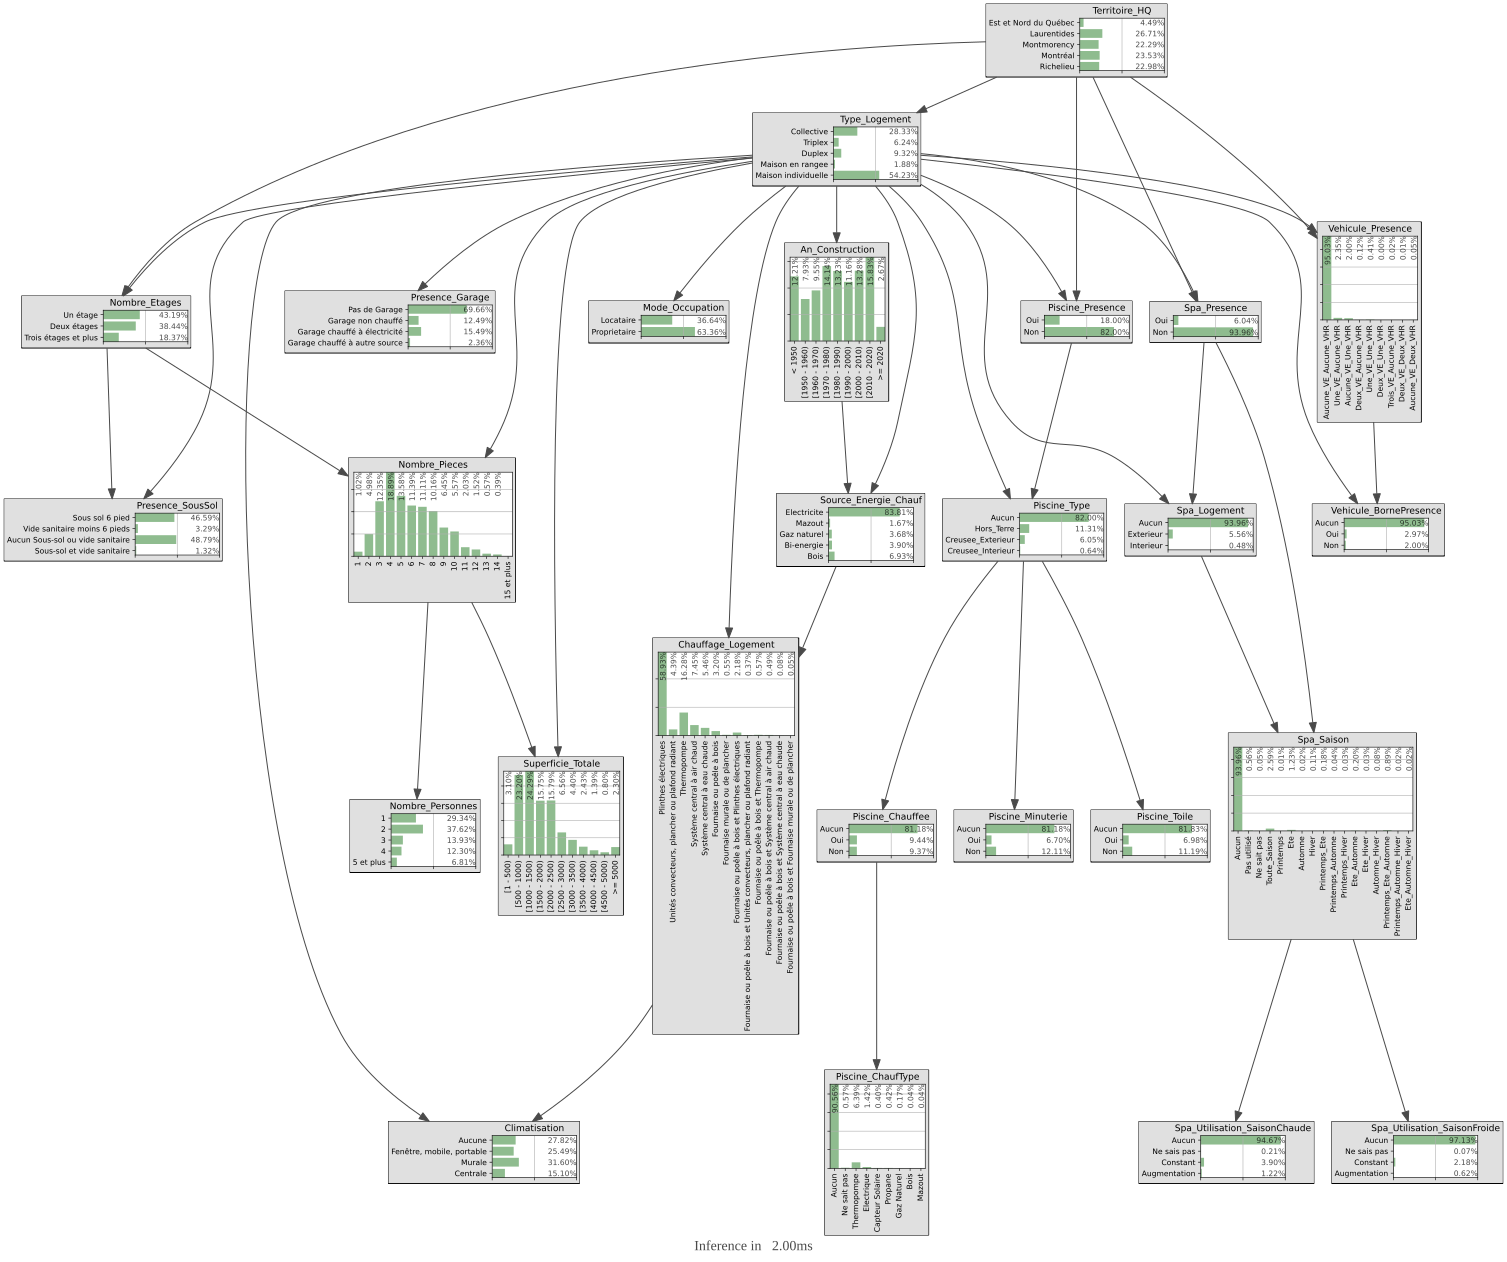

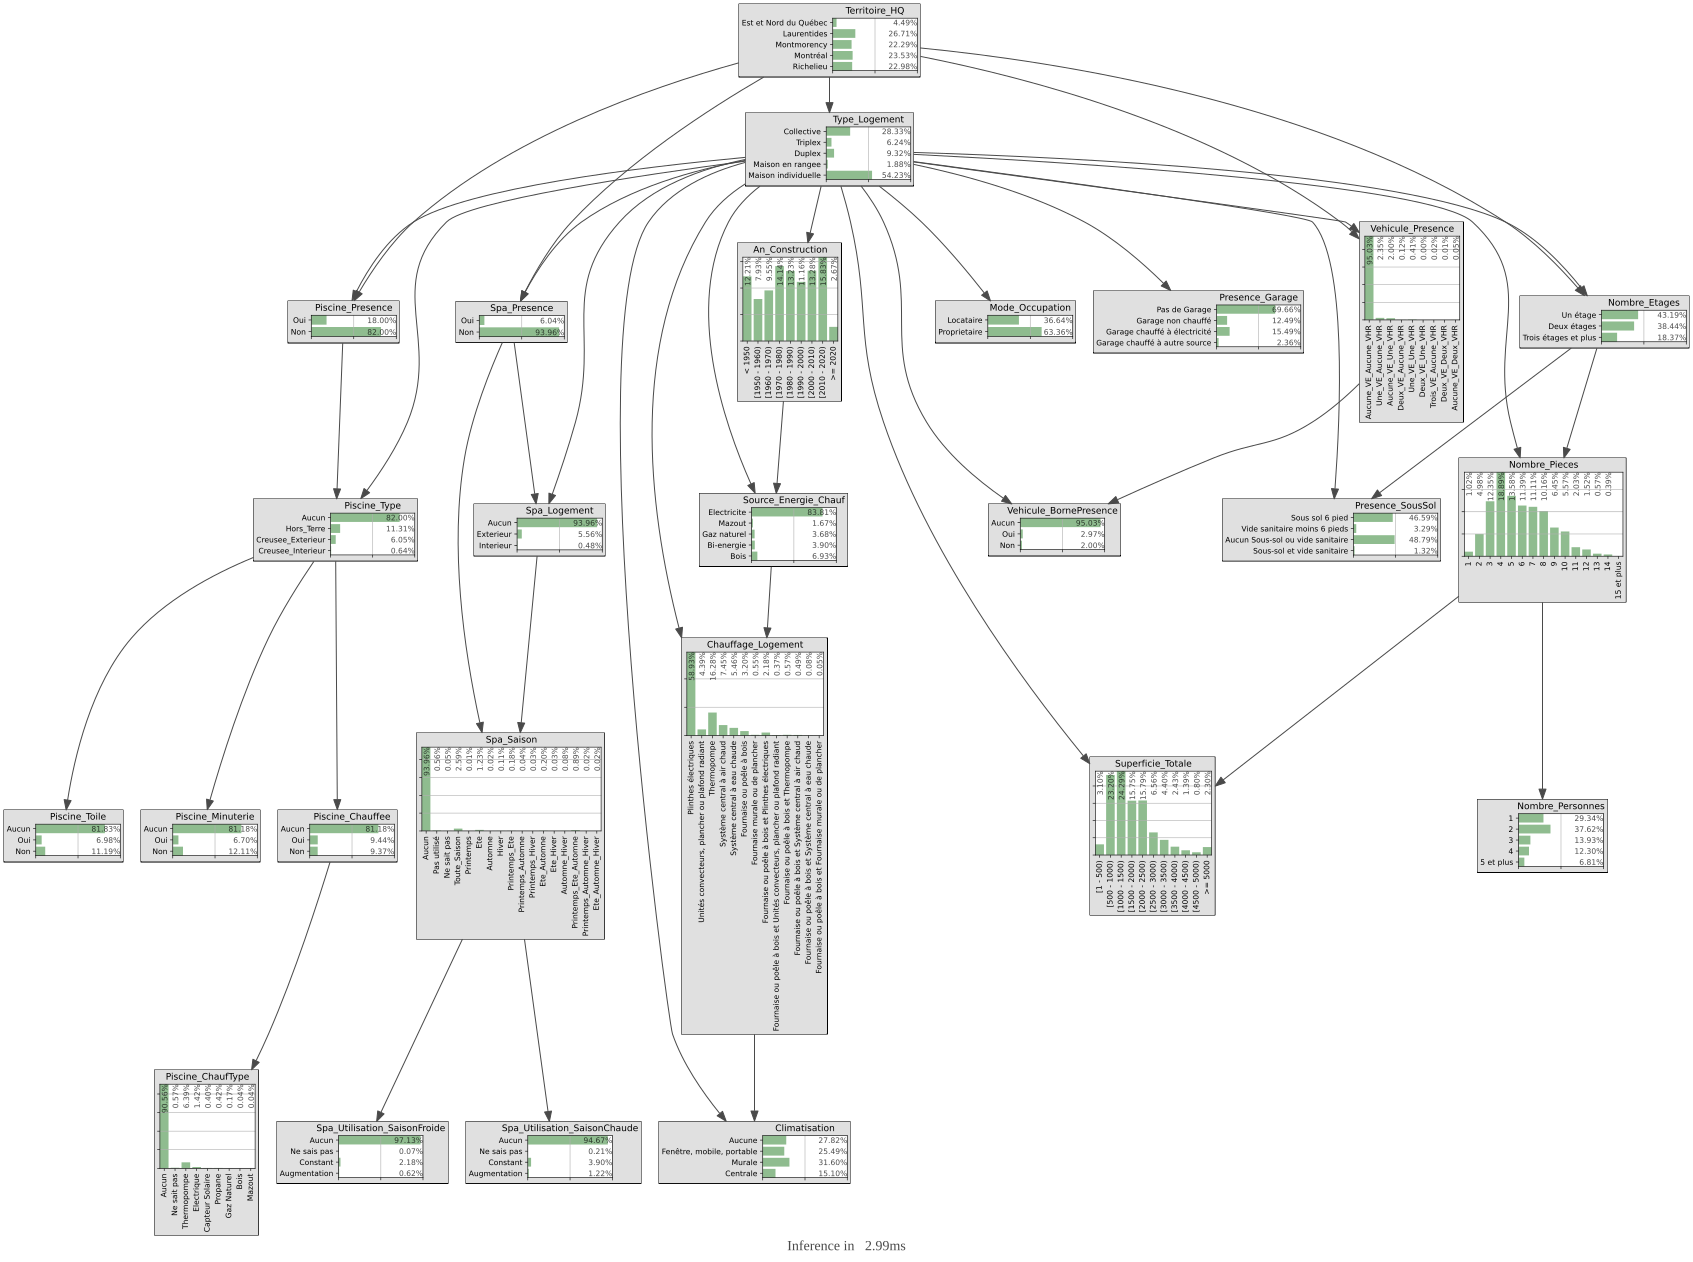

In [7]:
import pyagrum as gum
#import pyagrum.lib.ipython as gnb
import pyagrum.lib.notebook as gnb

# Load the Bayesian Network from the saved file
InsClsEUEMr_2 = EUEMr()
path = parent_dir+"/data/BayesianNetwork/BN_EUEMr.XDSL"
InsClsEUEMr_2.Load_BN(path)

# Display the Bayesian Network - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn,evs={},size = '30')

# Display the Bayesian Network - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn,evs={},size = '30')

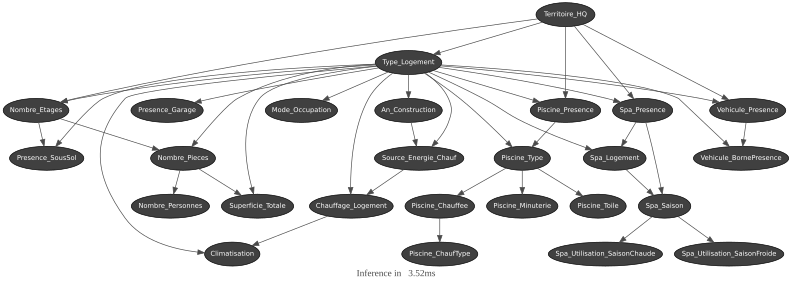

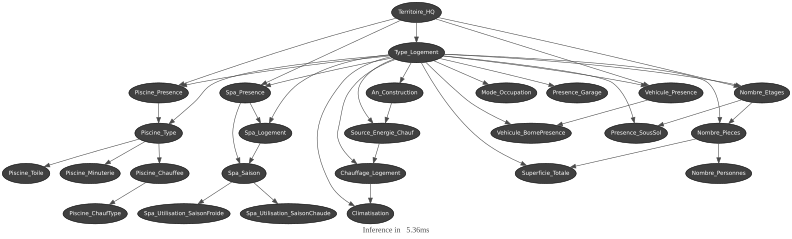

In [8]:
# Display the Bayesian Network - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn, evs={}, targets={"AnConstruction"}, size="11")

# Display the Bayesian Network - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn, evs={}, targets={"AnConstruction"}, size="11")


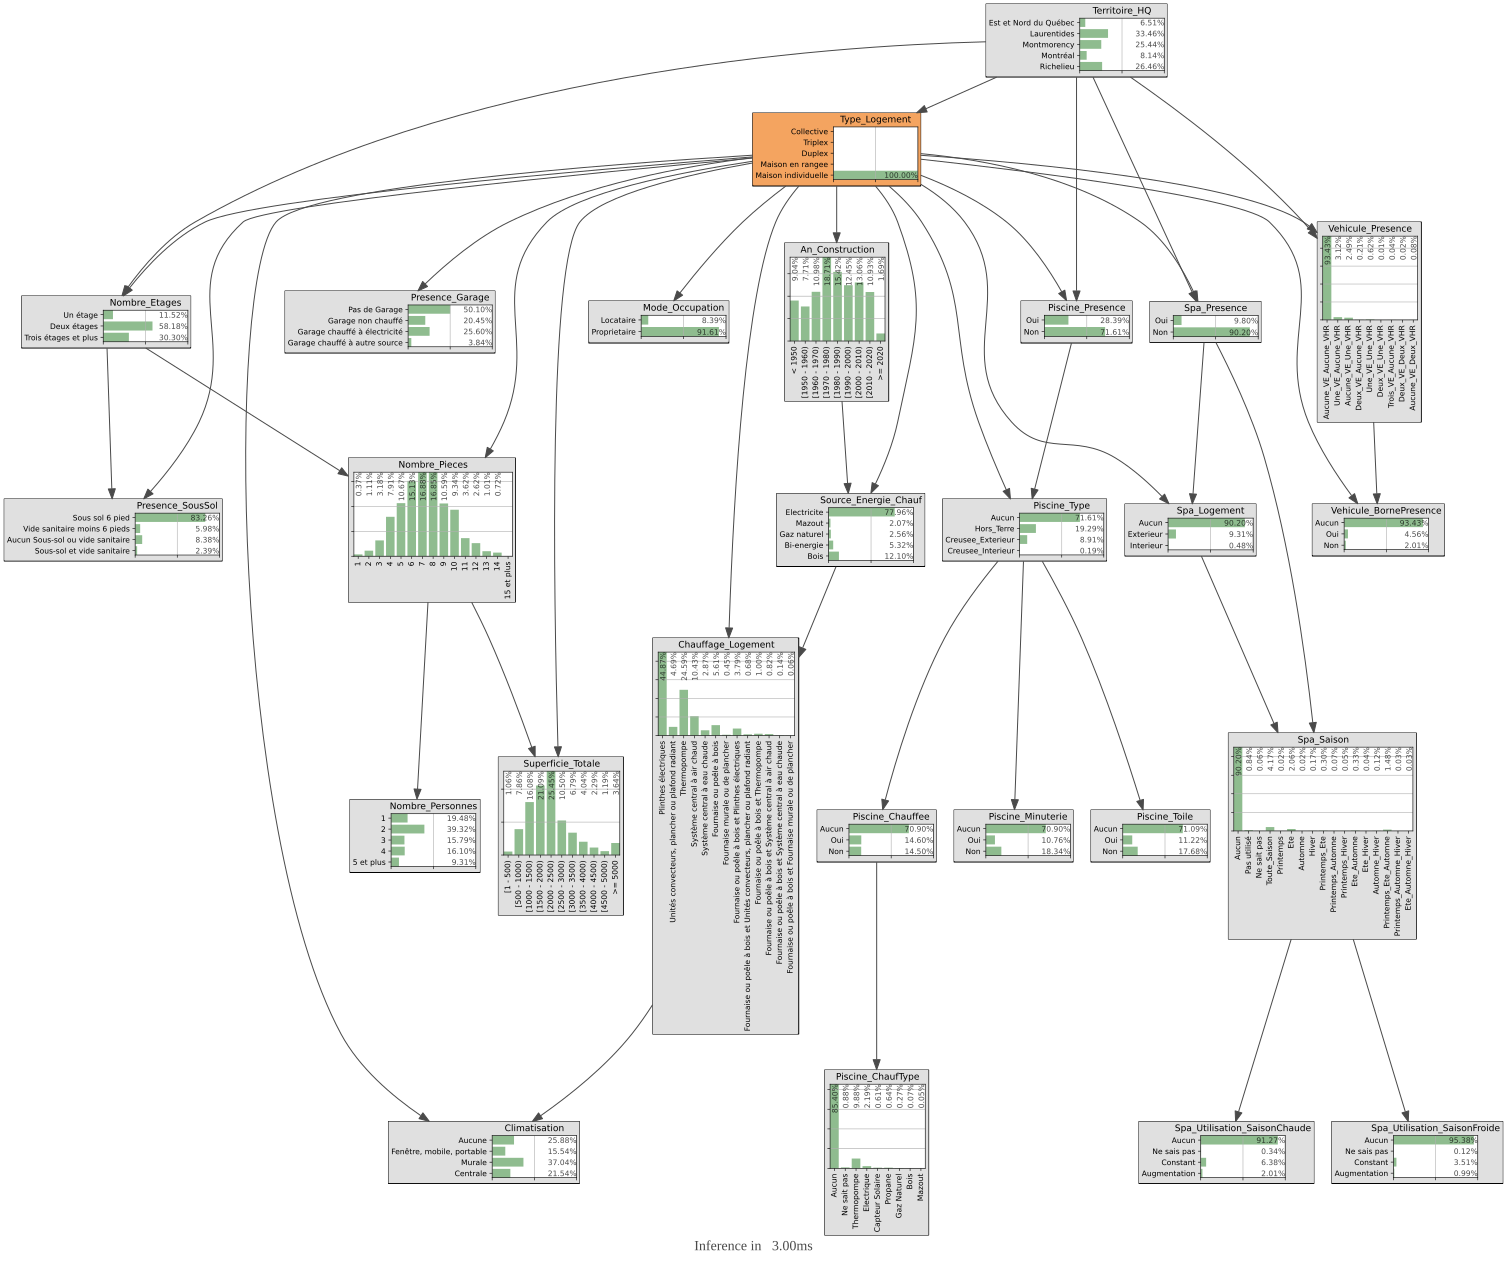

In [9]:
# Display the Bayesian Network with specific evidence - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn,evs={"Type_Logement": "Maison individuelle"},size = '30')

# Display the Bayesian Network with specific evidence - Apres enregistrement
#gnb.showInference(InsClsEUEMr_2.bn,evs={"Mode_Occupation": "Proprietaire"},size = '30')


In [10]:
Nombre_de_Samples = 3
Evidence = {"Mode_Occupation": "Proprietaire"}

# Fait un échantillonage - Avant enregistrement
df1 = InsClsEUEMr.do_Sampling(Nombre_de_Samples, evs = Evidence)

# Fait un échantillonage - Apres enregistrement
df2 = InsClsEUEMr_2.do_Sampling(Nombre_de_Samples, evs = Evidence)

# Affiche les échantillons - Avant enregistrement
df1, df2

(  Territoire_HQ        Type_Logement Piscine_Presence Piscine_Type  \
 0     Richelieu  Maison individuelle              Non        Aucun   
 1   Laurentides  Maison individuelle              Non        Aucun   
 2     Richelieu  Maison individuelle              Non        Aucun   
 
   Piscine_Minuterie Piscine_Chauffee Piscine_ChaufType Piscine_Toile  \
 0             Aucun            Aucun             Aucun         Aucun   
 1             Aucun            Aucun             Aucun         Aucun   
 2             Aucun            Aucun             Aucun         Aucun   
 
   Spa_Presence Spa_Logement  ...    Chauffage_Logement Climatisation  \
 0          Non        Aucun  ...  Plinthes électriques        Aucune   
 1          Non        Aucun  ...  Plinthes électriques        Murale   
 2          Non        Aucun  ...           Thermopompe      Centrale   
 
       Vehicule_Presence Vehicule_BornePresence Nombre_Etages  \
 0  Aucune_VE_Aucune_VHR                  Aucun      Un étage

In [11]:
#proportion de valeur
# Fait un échantillonage - Apres enregistrement
df3 = InsClsEUEMr_2.do_Sampling(1000, evs = {})

for col in df2.columns:
    print(col + ":" + str(df3[col].value_counts()/ len(df3)))


Territoire_HQ:Territoire_HQ
Laurentides              0.270
Richelieu                0.249
Montmorency              0.216
Montréal                 0.214
Est et Nord du Québec    0.051
Name: count, dtype: float64
Type_Logement:Type_Logement
Maison individuelle    0.574
Collective             0.254
Duplex                 0.093
Triplex                0.061
Maison en rangee       0.018
Name: count, dtype: float64
Presence_Garage:Presence_Garage
Pas de Garage                    0.668
Garage chauffé à électricité     0.159
Garage non chauffé               0.151
Garage chauffé à autre source    0.022
Name: count, dtype: float64
Vehicule_Presence:Vehicule_Presence
Aucune_VE_Aucune_VHR    0.945
Une_VE_Aucune_VHR       0.028
Aucune_VE_Une_VHR       0.018
Une_VE_Une_VHR          0.008
Aucune_VE_Deux_VHR      0.001
Name: count, dtype: float64
Vehicule_BornePresence:Vehicule_BornePresence
Aucun    0.945
Oui      0.040
Non      0.015
Name: count, dtype: float64
Piscine_Presence:Piscine_Presence
Non  